In [1]:
import numpy as np
import pandas as pd
import datetime
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
events_df = pd.read_csv('events.csv')
events_df

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN
2756097,1438399813142,762376,view,115946,NaN
2756098,1438397820527,1251746,view,78144,NaN
2756099,1438398530703,1184451,view,283392,NaN


In [4]:
all_customers = events_df['visitorid'].unique()
all_customers.size

1407580

In [5]:
customer_purchased = events_df[events_df['transactionid'].notnull()]['visitorid'].unique()
customer_purchased.size

11719

In [6]:
customer_browsed = [x for x in all_customers if x not in  customer_purchased]
len(customer_browsed)

1395861

In [7]:
events_df[events_df['visitorid'] == 102019].sort_values('timestamp')

,timestamp,visitorid,event,itemid,transactionid
19690,1433175714335,102019,view,49521,NaN
19501,1433175801314,102019,addtocart,49521,NaN
14842,1433175812596,102019,view,150318,NaN
19573,1433175871497,102019,view,49521,NaN
8701,1433175894837,102019,view,49521,NaN
19708,1433175945872,102019,view,150318,NaN
8740,1433176042269,102019,view,49521,NaN
814,1433176736375,102019,transaction,150318,13556.0
19724,1433176736422,102019,transaction,49521,13556.0


In [8]:
events_df['event'].unique()

array(['view', 'addtocart', 'transaction'], dtype=object)

In [9]:
events_df['timestamp'] = pd.to_datetime(events_df['timestamp'], unit='ms')

In [10]:
events_df

,timestamp,visitorid,event,itemid,transactionid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN
1,2015-06-02 05:50:14.164,992329,view,248676,NaN
2,2015-06-02 05:13:19.827,111016,view,318965,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN
4,2015-06-02 05:02:17.106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,2015-08-01 03:13:05.939,591435,view,261427,NaN
2756097,2015-08-01 03:30:13.142,762376,view,115946,NaN
2756098,2015-08-01 02:57:00.527,1251746,view,78144,NaN
2756099,2015-08-01 03:08:50.703,1184451,view,283392,NaN


In [11]:
events_count = events_df['event'].value_counts()
events_count

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

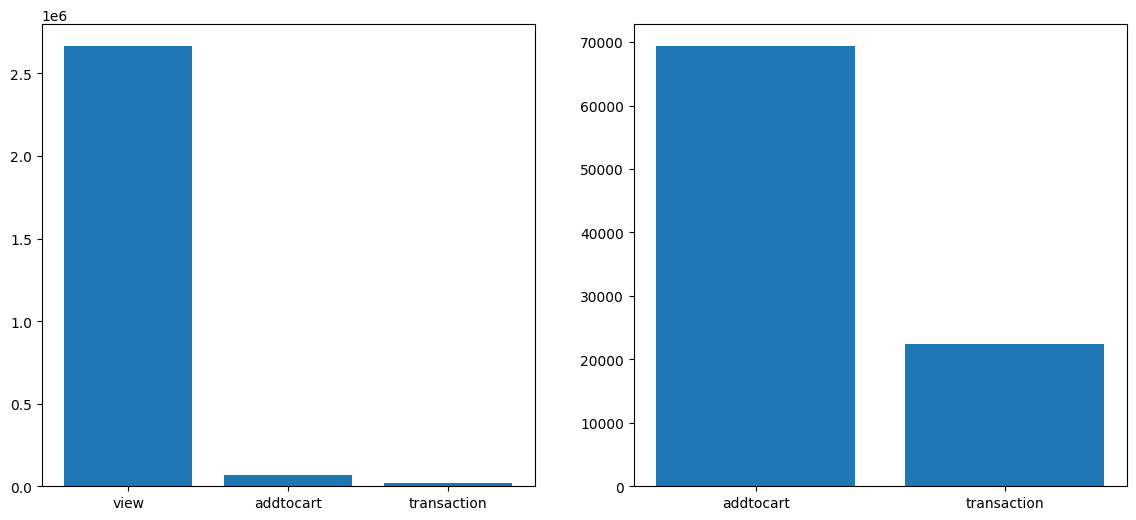

In [12]:
plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.bar(events_count.index, events_count.values)

plt.subplot(1,2,2)
plt.bar(events_count.index[1:], events_count.values[1:])

plt.show()

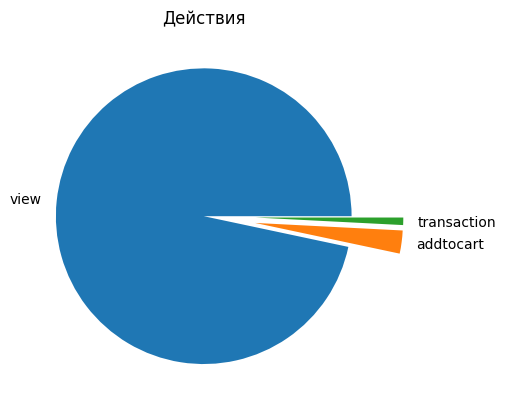

In [13]:
plt.title('Действия')
explode = (0, 0.35, 0.35)
plt.pie(events_count.values, explode = explode, labels = events_count.index)
plt.show()

In [14]:
events_df['transactionid'].dropna()

130         4000.0
304        11117.0
418         5444.0
814        13556.0
843         7244.0
            ...   
2755294     8354.0
2755349     3643.0
2755508     4385.0
2755603    13872.0
2755607    17579.0
Name: transactionid, Length: 22457, dtype: float64

In [15]:
events_df['itemid'].unique().size

235061

In [16]:
grupped = events_df.groupby('event')['itemid'].apply(np.array)
grupped

event
addtocart      [5206, 10572, 255275, 356475, 312728, 63312, 1...
transaction    [356475, 15335, 81345, 150318, 310791, 54058, ...
view           [355908, 248676, 318965, 253185, 367447, 22556...
Name: itemid, dtype: object

### Наиболее частые просмотры

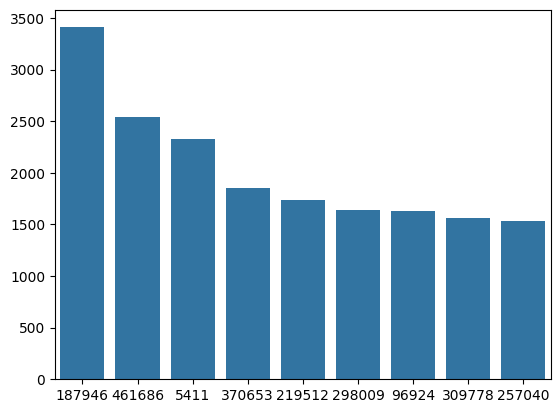

In [19]:
import operator
views = grupped['view']
count_view = {}
views = np.array(views[:])
unique, counts = np.unique(views, return_counts=True)
count_view = dict(zip(unique, counts))
sort_count_view = sorted(count_view.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_view[:9]]
y = [i[1] for i in sort_count_view[:9]]
sns.barplot(x=x,y=y,order=x)
plt.show()

### Наиболее частые добавления в корзину

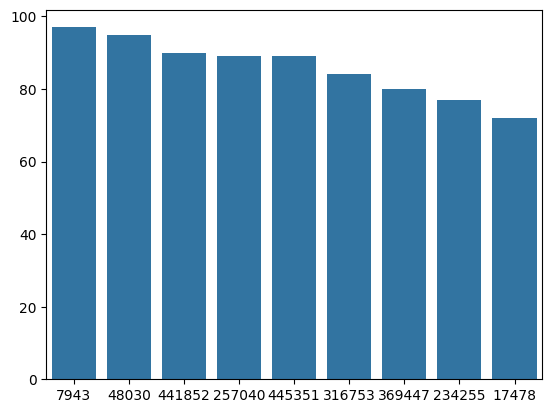

In [24]:
addtocart = grupped['addtocart']
count_addtocart = {}
addtocart = np.array(addtocart[:])
unique, counts = np.unique(addtocart, return_counts=True)
count_addtocart = dict(zip(unique, counts))
sort_count_addtocart = sorted(count_addtocart.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_addtocart[5:14]]
y = [i[1] for i in sort_count_addtocart[5:14]]
sns.barplot(x=x,y=y,order=x)
plt.show()

### Наиболее частые покупки

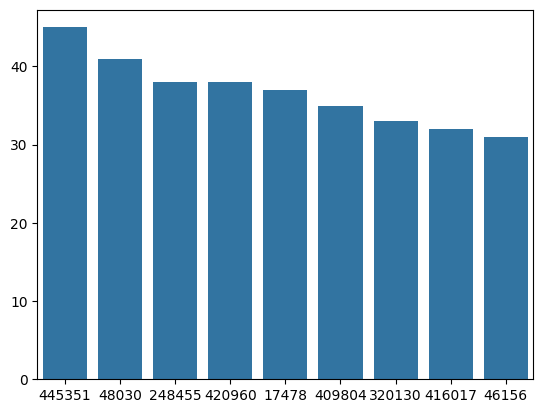

In [25]:
transaction = grupped['transaction']
count_transaction = {}
transaction = np.array(transaction[:])
unique, counts = np.unique(transaction, return_counts=True)
count_transaction = dict(zip(unique, counts))
sort_count_transaction = sorted(count_transaction.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_transaction[5:14]]
y = [i[1] for i in sort_count_transaction[5:14]]
sns.barplot(x=x,y=y,order=x)
plt.show()

In [26]:
customer_purchased = events_df[events_df['transactionid'].notnull()]['visitorid'].unique()

purchased_items = []
for customer in customer_purchased:
    purchased_items.append(list(events_df.loc[(events_df['visitorid'] == customer) & events_df['transactionid'].notnull()].itemid.values))


In [27]:
purchased_items[:7]

[[np.int64(356475)],
 [np.int64(15335),
  np.int64(380775),
  np.int64(237753),
  np.int64(317178),
  np.int64(12836),
  np.int64(400969),
  np.int64(105792),
  np.int64(25353),
  np.int64(200793),
  np.int64(80582),
  np.int64(302422)],
 [np.int64(81345)],
 [np.int64(150318), np.int64(49521)],
 [np.int64(310791), np.int64(299044)],
 [np.int64(54058),
  np.int64(284871),
  np.int64(251130),
  np.int64(268335),
  np.int64(183049),
  np.int64(261940),
  np.int64(369093),
  np.int64(370745),
  np.int64(192990),
  np.int64(277119),
  np.int64(241716),
  np.int64(283766),
  np.int64(16417),
  np.int64(217068),
  np.int64(36372),
  np.int64(68923),
  np.int64(428015),
  np.int64(69533),
  np.int64(13520),
  np.int64(385638),
  np.int64(442871),
  np.int64(136526),
  np.int64(247862),
  np.int64(93828),
  np.int64(230911),
  np.int64(382595),
  np.int64(34853),
  np.int64(216260),
  np.int64(154812),
  np.int64(445241),
  np.int64(57702),
  np.int64(347850),
  np.int64(151855),
  np.int64(226

In [28]:
def rec_items(item_id, purchased_items):
    rec_list = []
    for x in purchased_items:
        if item_id in x:
            rec_list += x
    rec_list = list(set(rec_list) - set([item_id]))
    return rec_list

In [34]:
rec_items(79484, purchased_items)

[np.int64(348352),
 np.int64(347974),
 np.int64(248840),
 np.int64(118856),
 np.int64(179784),
 np.int64(134858),
 np.int64(390857),
 np.int64(204494),
 np.int64(429498),
 np.int64(42002),
 np.int64(339032),
 np.int64(330786),
 np.int64(97890),
 np.int64(348326),
 np.int64(398887),
 np.int64(283816),
 np.int64(85416),
 np.int64(389158),
 np.int64(338794),
 np.int64(307322),
 np.int64(384302),
 np.int64(243566),
 np.int64(316722),
 np.int64(196148),
 np.int64(465333),
 np.int64(89142),
 np.int64(223162),
 np.int64(211579),
 np.int64(188669)]